Cell 1: Mount Drive & Set Working Directory

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Switch to the project directory containing the datasets and the notebook
WORKING_DIR = '/content/drive/MyDrive/FTEC5560'
import os
os.chdir(WORKING_DIR)
print(f"Changed working directory to: {os.getcwd()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Changed working directory to: /content/drive/MyDrive/FTEC5560


Cell 2: Install Libraries

In [ ]:
!pip install openai numpy pandas scipy matplotlib seaborn pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.8/204.8 kB 4.6 MB/s eta 0:00:00


Cell 3: Import Libraries, Define Configuration, and Helper Functions

In [ ]:
import random
import numpy as np
import pandas as pd
from openai import OpenAI
from scipy.stats import norm
import os
import glob
from google.colab import userdata
import time
import json
import re

API_KEY_ENV = userdata.get('siliconflow_api_key')
BASE_URL = "https://api.siliconflow.cn/v1"

MODELS_TO_TEST = [
    "Qwen/Qwen3-32B",
    "deepseek-ai/DeepSeek-V3.2",
]
# Define N-back levels and other parameters
N_BACK_VALUES = [1, 2, 3]
TEMPERATURES_TO_TEST = [0.7]
NUM_BLOCKS_PER_N = 5 # Number of blocks to run per N-back condition

DATASET_PATHS = {
    1: "1back/",
    2: "2back/",
    3: "3back/",
}

TRIALS_PER_BLOCK = 24 # Number of trials per block

def load_sequence_and_targets_from_file(file_path):
    """Loads letter sequence and target labels from a text file with two lines."""
    with open(file_path, 'r') as f:
        lines = f.readlines()

    if len(lines) < 2:
        raise ValueError(f"File {file_path} does not contain enough lines (expected 2).")

    sequence_line = lines[0].strip()  # First line is the sequence
    targets_line = lines[1].strip()   # Second line is the targets

    if len(sequence_line) != TRIALS_PER_BLOCK or len(targets_line) != TRIALS_PER_BLOCK:
        raise ValueError(f"Incorrect file format for {file_path}. Expected {TRIALS_PER_BLOCK} letters and {TRIALS_PER_BLOCK} targets.")

    sequence = list(sequence_line.upper())
    targets = list(targets_line.lower())
    return sequence, targets

def get_model_response(client, full_conversation_history, model_name, temperature=0.7):
    """
    Calls the LLM API to get a response based on the full conversation history.
    """
    start_time = time.time()
    try:
        completion = client.chat.completions.create(
            model=model_name,
            messages=full_conversation_history,
            max_tokens=10,
            temperature=temperature,
        )
        response_time = time.time() - start_time
        response_text = completion.choices[0].message.content.strip().lower()

        # Print the raw API response and response time
        print(f"      Raw API Response: '{response_text}', RT: {response_time:.2f}s")

        if not response_text:
            print("        WARNING: Empty response received.")
            return '-', response_time

        first_char = response_text[0]
        if first_char == 'm':
            return 'm', response_time
        elif first_char in ['-', 'n']:
            return '-', response_time
        else:
            print(f"        Rule violation! Extracting first char: '{first_char}'")
            return ('m' if first_char == 'm' else '-'), response_time

    except Exception as e:
        print(f"        API Error: {e}")
        return '-', np.nan

def calculate_metrics_per_block(targets, responses):
    """Calculates d-prime, accuracy, etc., for a block."""
    if len(targets) != len(responses):
        raise ValueError("Targets and responses must have the same length.")

    hits = sum(1 for t, r in zip(targets, responses) if t == 'm' and r == 'm')
    misses = sum(1 for t, r in zip(targets, responses) if t == 'm' and r == '-')
    fas = sum(1 for t, r in zip(targets, responses) if t == '-' and r == 'm')
    crs = sum(1 for t, r in zip(targets, responses) if t == '-' and r == '-')

    total_signal = hits + misses
    total_noise = fas + crs

    hit_rate = hits / total_signal if total_signal > 0 else 0.0
    fa_rate = fas / total_noise if total_noise > 0 else 0.0
    accuracy = (hits + crs) / len(targets) if targets else 0.0

    epsilon = 1e-9
    corrected_hr = np.clip(hit_rate, epsilon, 1 - epsilon)
    corrected_far = np.clip(fa_rate, epsilon, 1 - epsilon)
    d_prime = norm.ppf(corrected_hr) - norm.ppf(corrected_far)

    return {
        'hit_rate': hit_rate, 'fa_rate': fa_rate,
        'accuracy': accuracy, 'd_prime': d_prime,
        'hits': hits, 'misses': misses, 'fas': fas, 'crs': crs
    }

def run_single_condition(n_back, num_blocks, client, model_name, temp_value, condition_label):
    """Runs a single experimental condition (model, N-back, temp) for a number of blocks."""
    dataset_path = DATASET_PATHS.get(n_back)
    if not dataset_path or not os.path.isdir(dataset_path):
        print(f"WARNING: Dataset path for {n_back}-back ({dataset_path}) does not exist. Skipping {condition_label}.")
        return pd.DataFrame()

    results = []
    all_files = glob.glob(os.path.join(dataset_path, "*.txt"))

    # Sort files numerically based on the integer part of the filename
    def extract_number(filepath):
        filename = os.path.basename(filepath)
        match = re.search(r'(\d+)', filename)
        return int(match.group(1)) if match else float('inf') # Handle unexpected filenames gracefully

    all_files.sort(key=extract_number)
    selected_files = all_files[:num_blocks]

    if not selected_files:
        print(f"WARNING: No .txt files found in {dataset_path}. Skipping {condition_label}.")
        return pd.DataFrame()

    print(f"Starting {condition_label}...")
    for idx, file_path in enumerate(selected_files):
        block_id = int(os.path.basename(file_path).split('.')[0])
        print(f"  Processing Block {block_id}...")

        sequence, targets = load_sequence_and_targets_from_file(file_path)
        responses = []
        response_times = []

        system_prompt = f"You are performing a {n_back}-back task. Respond 'm' if the current letter matches the one {n_back} positions back, otherwise respond '-'. Only 'm' or '-' without explanation."
        full_conversation_history = [{"role": "system", "content": system_prompt}]

        for i, current_letter in enumerate(sequence):
            full_conversation_history.append({"role": "user", "content": current_letter})
            try:
                resp, rt = get_model_response(client, full_conversation_history, model_name, temperature=temp_value)
                responses.append(resp)
                response_times.append(rt)
                full_conversation_history.append({"role": "assistant", "content": resp})
            except Exception as e:
                print(f"Error on trial {i} (Letter '{current_letter}'): {e}")
                responses.append('-')
                response_times.append(np.nan)
                full_conversation_history.append({"role": "assistant", "content": "-"})

        if len(responses) == len(targets):
            block_metrics = calculate_metrics_per_block(targets, responses)
            block_metrics.update({
                'block_id': block_id, 'model': model_name, 'n_back': n_back,
                'temperature': temp_value, 'avg_rt': np.mean([t for t in response_times if not np.isnan(t)]),
                'condition': condition_label
            })
            results.append(block_metrics)
            print(f"    Block {block_id} complete. d': {block_metrics['d_prime']:.3f}")

    print(f"Completed {condition_label}.\n")
    return pd.DataFrame(results)

# Initialize the OpenAI client
client = OpenAI(api_key=API_KEY_ENV, base_url=BASE_URL)

Cell 4: Main Experiment Runner

In [ ]:
print("--- Running New Experiments ---")
all_results_df = pd.DataFrame()

for model_name in MODELS_TO_TEST:
    for n_val in N_BACK_VALUES:
        for temp_val in TEMPERATURES_TO_TEST:
            condition_label = f"{model_name.split('/')[-1]}_T{temp_val}_{n_val}back"
            df = run_single_condition(
                n_back=n_val, num_blocks=NUM_BLOCKS_PER_N, client=client,
                model_name=model_name, temp_value=temp_val, condition_label=condition_label
            )
            all_results_df = pd.concat([all_results_df, df], ignore_index=True)

# Save the new experiment results
output_filename = "llm_nback_results_new_experiment.csv"
all_results_df.to_csv(output_filename, index=False)
print(f"\nNew experiment results saved to {output_filename}")
print(f"Shape of new results: {all_results_df.shape}")

--- Running New Experiments ---
Starting Qwen3-32B_T0.7_1back...
  Processing Block 0...
      Raw API Response: '-', RT: 8.28s
      Raw API Response: '-', RT: 12.93s
      Raw API Response: '-', RT: 13.70s
      Raw API Response: '-', RT: 8.18s
      Raw API Response: 'm', RT: 6.33s
      Raw API Response: 'm', RT: 10.58s
      Raw API Response: '-', RT: 6.91s
      Raw API Response: '-', RT: 15.51s
      Raw API Response: 'm', RT: 18.30s
      Raw API Response: 'm', RT: 12.65s
      Raw API Response: 'm', RT: 4.97s
      Raw API Response: '-', RT: 9.10s
      Raw API Response: 'm', RT: 13.07s
      Raw API Response: '-', RT: 9.74s
      Raw API Response: '-', RT: 4.65s
      Raw API Response: '-', RT: 4.73s
      Raw API Response: 'm', RT: 8.37s
      Raw API Response: 'm', RT: 13.02s
      Raw API Response: '-', RT: 5.78s
      Raw API Response: '-', RT: 7.41s
      Raw API Response: '-', RT: 9.69s
      Raw API Response: 'm', RT: 21.52s
      Raw API Response: '-', RT: 4.86s
     

Cell 5: Load and Integrate Data

In [ ]:
import pandas as pd
import numpy as np
import json
from scipy.stats import norm, kruskal
from pingouin import rm_anova, pairwise_ttests
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load New LLM Experiment Data (from CSV) ---
NEW_CSV_PATH = "llm_nback_results_new_experiment.csv"
try:
    new_llm_df = pd.read_csv(NEW_CSV_PATH)
    print(f"Loaded new LLM data: {new_llm_df.shape[0]} rows")
except FileNotFoundError:
    print(f"ERROR: File not found at {NEW_CSV_PATH}")
    new_llm_df = pd.DataFrame()

# --- Load Original GPT-3.5-Turbo Data (from JSON) ---
ORIG_JSON_PATH = "all_trials_verbal.json"

with open(ORIG_JSON_PATH, 'r') as f:
    orig_data = json.load(f)

# --- Process Original JSON into a DataFrame ---
orig_rows = []
for key, trials_list in orig_data.items():
    parts = key.split('_')
    n_back_level_str = parts[0]
    block_id = int(parts[1])
    n_back_level = int(n_back_level_str.replace('back', ''))

    responses = [trial.get('response', '-') for trial in trials_list]
    targets = [trial.get('target', '-') for trial in trials_list]

    hits = sum(1 for t, r in zip(targets, responses) if t == 'm' and r == 'm')
    misses = sum(1 for t, r in zip(targets, responses) if t == 'm' and r == '-')
    fas = sum(1 for t, r in zip(targets, responses) if t == '-' and r == 'm')
    crs = sum(1 for t, r in zip(targets, responses) if t == '-' and r == '-')

    total_signal = hits + misses
    total_noise = fas + crs

    hit_rate = hits / total_signal if total_signal > 0 else 0.0
    fa_rate = fas / total_noise if total_noise > 0 else 0.0
    accuracy = (hits + crs) / len(targets) if targets else 0.0

    epsilon = 1e-9
    corrected_hr = np.clip(hit_rate, epsilon, 1 - epsilon)
    corrected_far = np.clip(fa_rate, epsilon, 1 - epsilon)
    d_prime = norm.ppf(corrected_hr) - norm.ppf(corrected_far)

    orig_rows.append({
        'block_id': f'gpt_orig_{block_id}',
        'model': 'gpt-3.5-turbo',
        'n_back': n_back_level,
        'temperature': 0.7,
        'condition': f'gpt-3.5-turbo_T0.7_{n_back_level}back',
        'hit_rate': hit_rate,
        'fa_rate': fa_rate,
        'accuracy': accuracy,
        'd_prime': d_prime,
        'hits': hits,
        'misses': misses,
        'fas': fas,
        'crs': crs,
        'avg_rt': np.nan,
    })

orig_df = pd.DataFrame(orig_rows)
print(f"Loaded original GPT-3.5-Turbo data: {orig_df.shape[0]} rows")

# --- Combine Datasets ---
if not new_llm_df.empty:
    combined_df = pd.concat([orig_df, new_llm_df], ignore_index=True)
    print(f"Combined dataset shape: {combined_df.shape[0]} rows")
    print(f"Models in combined dataset: {sorted(combined_df['model'].unique())}")
else:
    combined_df = orig_df.copy()
    print("Combined dataset contains only original data.")

# Display summary statistics
print("\n--- Summary of Combined Dataset (Mean ± Std) ---")
summary_stats = combined_df.groupby(['model', 'n_back']).agg({
    'd_prime': ['mean', 'std'],
    'accuracy': ['mean', 'std'],
    'hit_rate': ['mean', 'std'],
    'fa_rate': ['mean', 'std']
}).round(3)
print(summary_stats)

# Add a column for easier plotting distinction
combined_df['data_source'] = combined_df['model'].apply(lambda x: 'Original GPT-3.5' if x == 'gpt-3.5-turbo' else 'New LLMs')

Loaded new LLM data: 30 rows
Loaded original GPT-3.5-Turbo data: 150 rows
Combined dataset shape: 180 rows
Models in combined dataset: ['Qwen/Qwen3-32B', 'deepseek-ai/DeepSeek-V3.2', 'gpt-3.5-turbo']

--- Summary of Combined Dataset (Mean ± Std) ---
                                 d_prime        accuracy        hit_rate  \
                                    mean    std     mean    std     mean   
model                     n_back                                           
Qwen/Qwen3-32B            1        6.219  2.269    0.933  0.037    0.875   
                          2       11.026  2.168    0.992  0.019    0.975   
                          3        7.035  3.309    0.942  0.037    0.850   
deepseek-ai/DeepSeek-V3.2 1       11.996  0.000    1.000  0.000    1.000   
                          2        3.365  2.862    0.817  0.076    0.575   
                          3        1.929  2.300    0.742  0.062    0.350   
gpt-3.5-turbo             1        7.718  2.824    0.947  0.041   

Cell 6: Analyze Individual Model Performance

In [ ]:
models_to_analyze = combined_df['model'].unique()
metrics_to_test = ['d_prime', 'accuracy', 'hit_rate', 'fa_rate']

for model_name in models_to_analyze:
    print(f"\n--- Analysis for {model_name} ---")
    model_data = combined_df[combined_df['model'] == model_name]

    for metric in metrics_to_test:
        print(f"\nAnalyzing {metric}:")

        anova_data = model_data[['n_back', metric]].dropna()

        # 1. Repeated Measures ANOVA
        try:
            aov = rm_anova(data=anova_data, dv=metric, within='n_back', subject='block_id')
            print(f"RM ANOVA for {model_name} {metric}:")
            print(aov.round(3))

            if aov['p-GG-corr'].iloc[0] < 0.05 or aov['p-unc'].iloc[0] < 0.05:
                posthoc = pairwise_ttests(data=anova_data, dv=metric, within='n_back', subject='block_id', padjust='bonf')
                print(f"\nPost-hoc (Bonferroni-corrected) for {model_name} {metric}:")
                print(posthoc.round(3))
        except Exception as e:
            print(f"  RM ANOVA failed for {model_name} {metric}: {e}. Trying non-parametric test...")

            # 2. Non-parametric alternative: Kruskal-Wallis H Test
            try:
                groups = [group[metric].values for name, group in anova_data.groupby('n_back')]
                h_stat, p_val = kruskal(*groups)
                print(f"  Kruskal-Wallis H-test for {model_name} {metric}: H={h_stat:.3f}, p={p_val:.3f}")

                if p_val < 0.05:
                    print(f"    Post-hoc Mann-Whitney U tests would be needed for pairwise comparisons.")
            except Exception as e2:
                print(f"    Non-parametric test also failed: {e2}")


--- Analysis for gpt-3.5-turbo ---

Analyzing d_prime:
  RM ANOVA failed for gpt-3.5-turbo d_prime: 'block_id'. Trying non-parametric test...
  Kruskal-Wallis H-test for gpt-3.5-turbo d_prime: H=82.581, p=0.000
    Post-hoc Mann-Whitney U tests would be needed for pairwise comparisons.

Analyzing accuracy:
  RM ANOVA failed for gpt-3.5-turbo accuracy: 'block_id'. Trying non-parametric test...
  Kruskal-Wallis H-test for gpt-3.5-turbo accuracy: H=102.215, p=0.000
    Post-hoc Mann-Whitney U tests would be needed for pairwise comparisons.

Analyzing hit_rate:
  RM ANOVA failed for gpt-3.5-turbo hit_rate: 'block_id'. Trying non-parametric test...
  Kruskal-Wallis H-test for gpt-3.5-turbo hit_rate: H=104.941, p=0.000
    Post-hoc Mann-Whitney U tests would be needed for pairwise comparisons.

Analyzing fa_rate:
  RM ANOVA failed for gpt-3.5-turbo fa_rate: 'block_id'. Trying non-parametric test...
  Kruskal-Wallis H-test for gpt-3.5-turbo fa_rate: H=13.202, p=0.001
    Post-hoc Mann-Whitne

Cell 7: Compare Models Across Conditions

In [ ]:
from statsmodels.stats.anova import AnovaRM
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm

metrics_to_test = ['d_prime', 'accuracy', 'hit_rate', 'fa_rate']

print("--- Mixed-Design Analysis (Model x N-back) ---")
print("Note: This is a simplified version treating 'block_id' as a random factor implicitly.\n")

for metric in metrics_to_test:
    print(f"Analyzing {metric} across models and N-back levels:")
    analysis_data = combined_df[['model', 'n_back', 'block_id', metric]].dropna()
    analysis_data['n_back'] = analysis_data['n_back'].astype(str)

    # --- Attempt Mixed-Effects Model ---
    formula = f"{metric} ~ C(model) * C(n_back)"
    try:
        md = mixedlm(formula, data=analysis_data, groups=analysis_data['block_id'])
        mdf = md.fit()
        print(mdf.summary().tables[1]) # Print coefficients table

        print("\n--- Approximate ANOVA Table from Mixed Model ---")
        anova_lm_res = sm.stats.anova_lm(mdf, typ=2)
        print(anova_lm_res.round(3))

    except Exception as e:
        print(f"  Mixed-Effects Model failed for {metric}: {e}")
        print("  Falling back to standard 2-way ANOVA.")
        try:
            import pingouin as pg
            aov_2way = pg.anova(data=analysis_data, dv=metric, between=['model', 'n_back'], detailed=True)
            print(aov_2way.round(3))
        except Exception as e2:
            print(f"    Standard 2-way ANOVA also failed: {e2}")

    print("-" * 20)

--- Mixed-Design Analysis (Model x N-back) ---
Note: This is a simplified version treating 'block_id' as a random factor implicitly.

Analyzing d_prime across models and N-back levels:
  Mixed-Effects Model failed for d_prime: '<' not supported between instances of 'str' and 'int'
  Falling back to standard 2-way ANOVA.
           Source        SS     DF       MS       F  p_unc    np2
0           model   192.348    2.0   96.174  12.382    0.0  0.127
1          n_back   883.192    2.0  441.596  56.855    0.0  0.399
2  model * n_back   285.712    4.0   71.428   9.196    0.0  0.177
3        Residual  1328.160  171.0    7.767     NaN    NaN    NaN
--------------------
Analyzing accuracy across models and N-back levels:
  Mixed-Effects Model failed for accuracy: '<' not supported between instances of 'str' and 'int'
  Falling back to standard 2-way ANOVA.
           Source     SS     DF     MS        F  p_unc    np2
0           model  0.339    2.0  0.170   52.540    0.0  0.381
1          n_

Cell 8: Visualize All Results

Distribution plot for d_prime:


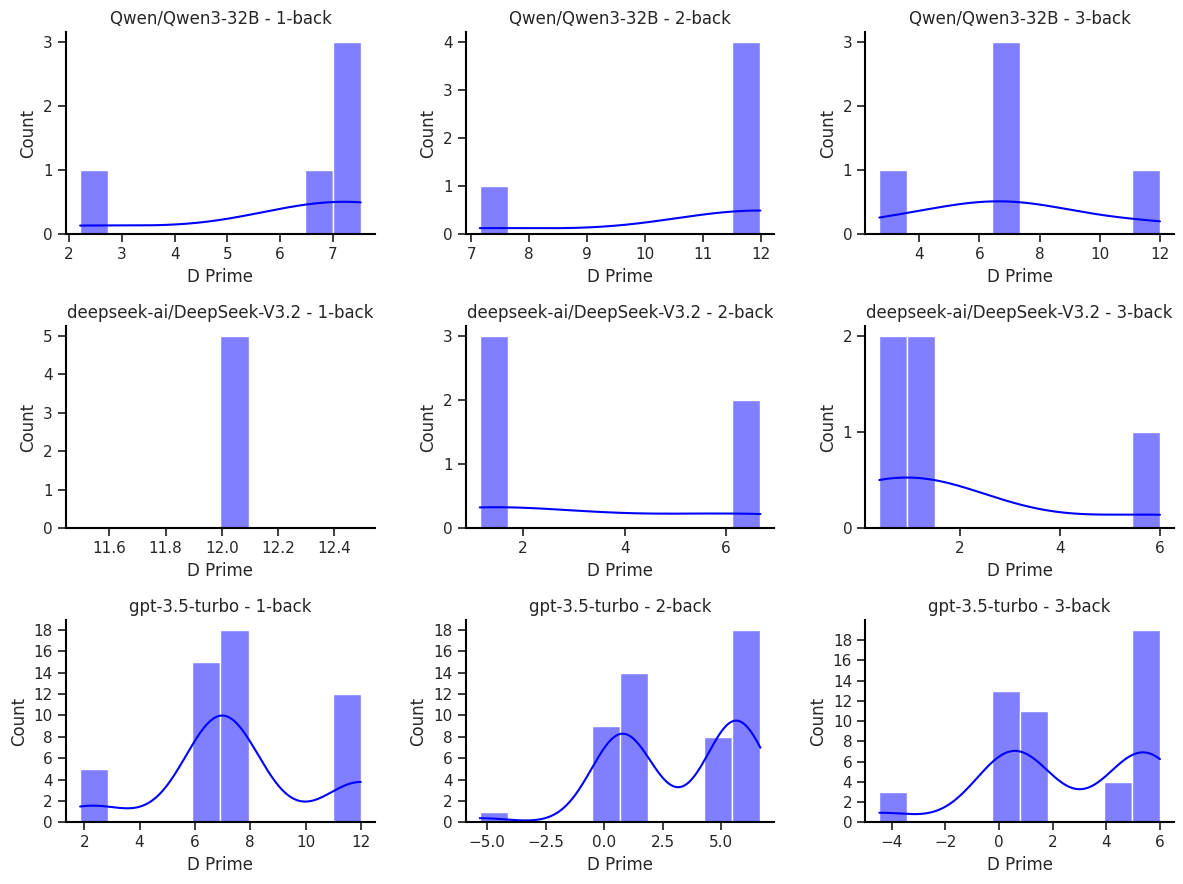

Distribution plot for accuracy:


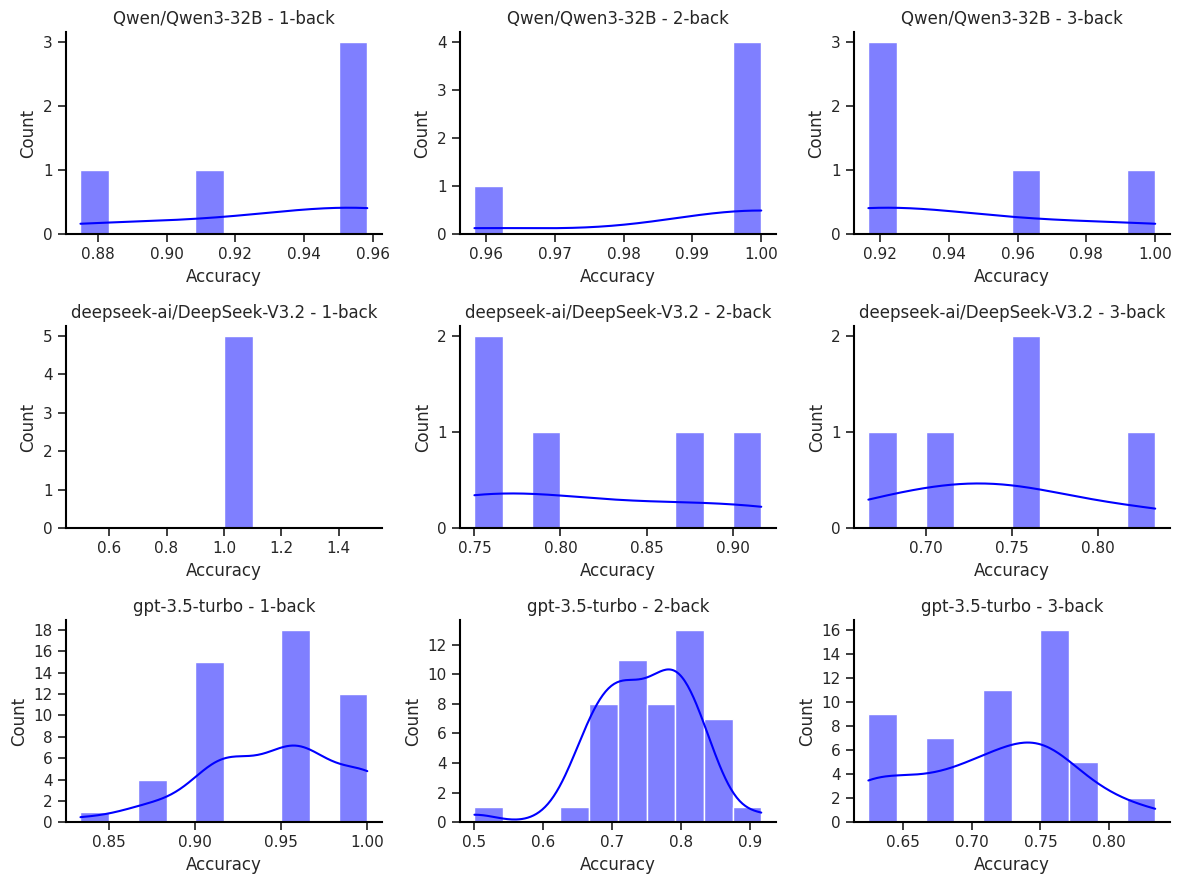

Distribution plot for hit_rate:


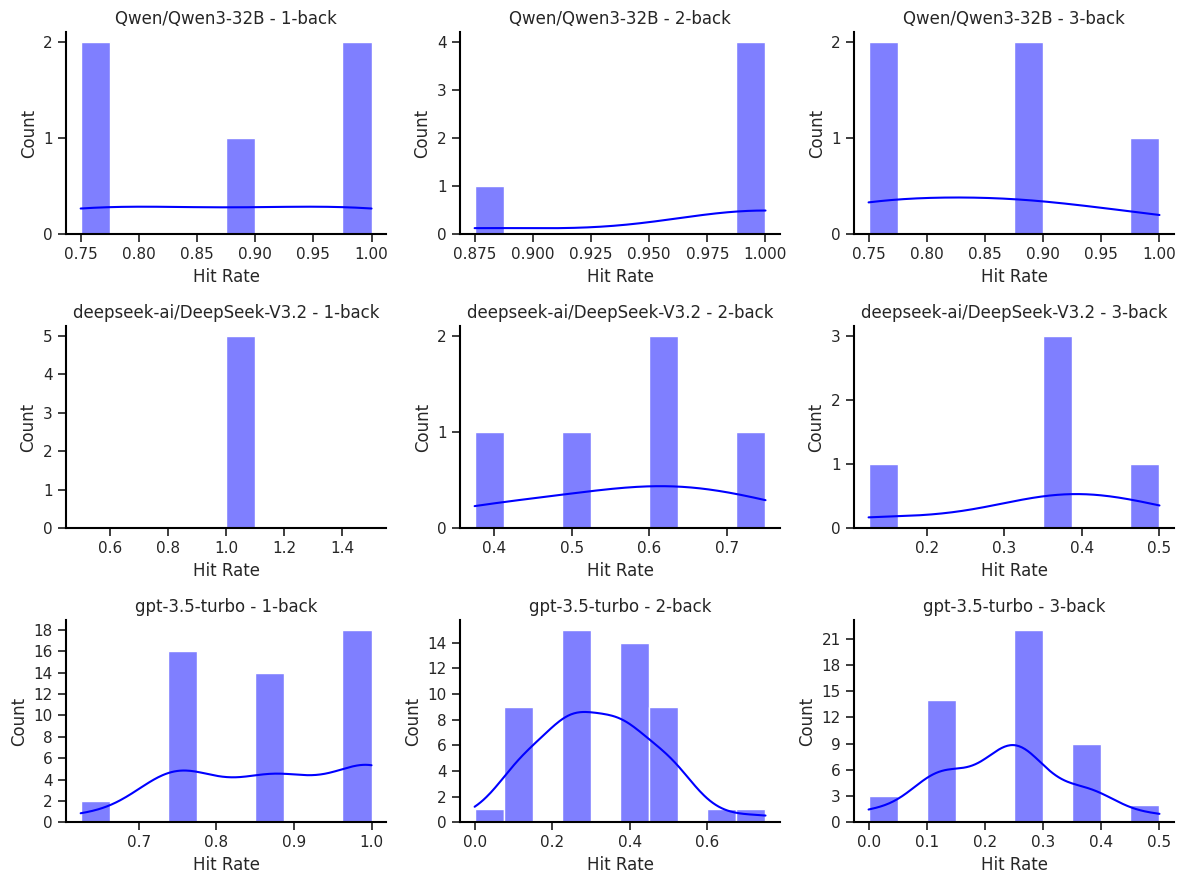

Distribution plot for fa_rate:


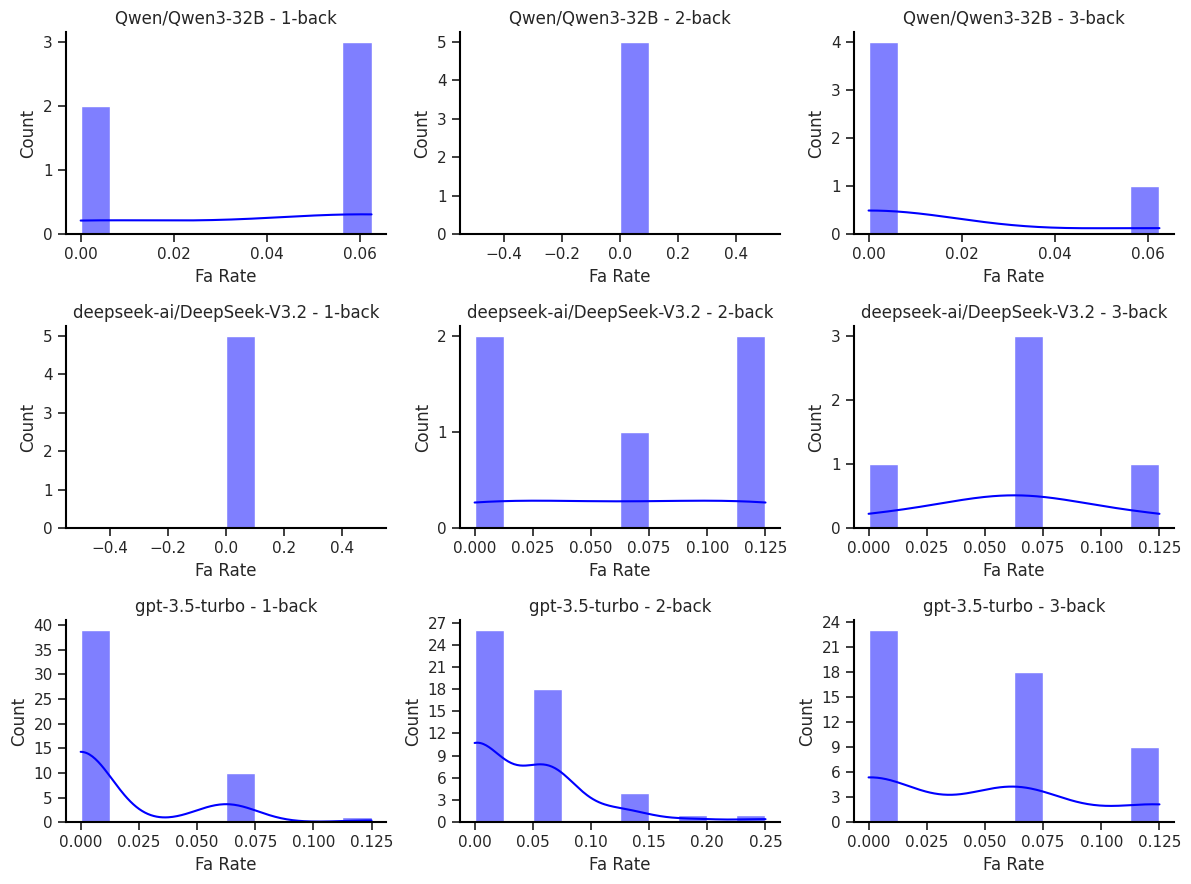

Boxplot for d_prime by N-back Level (Models Compared):


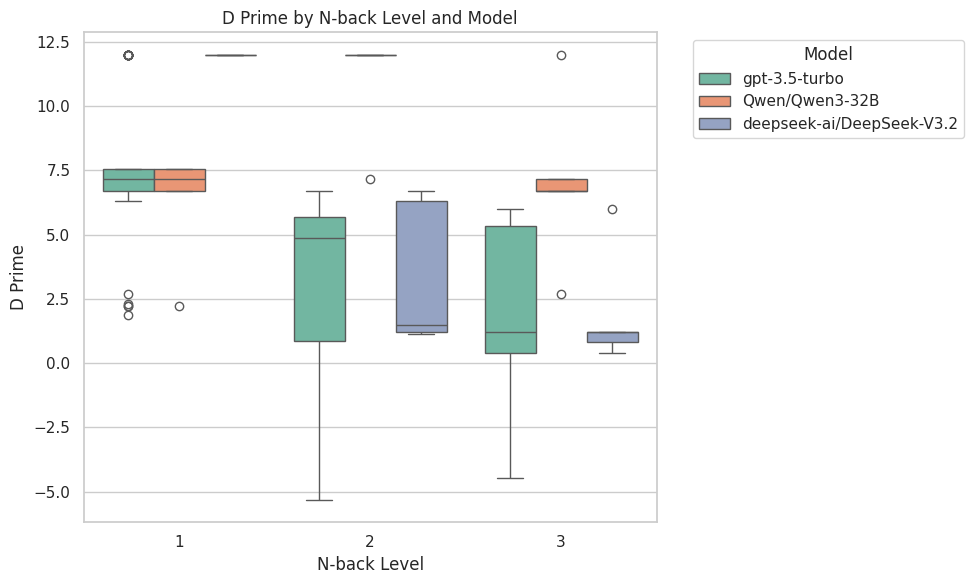

Boxplot for accuracy by N-back Level (Models Compared):


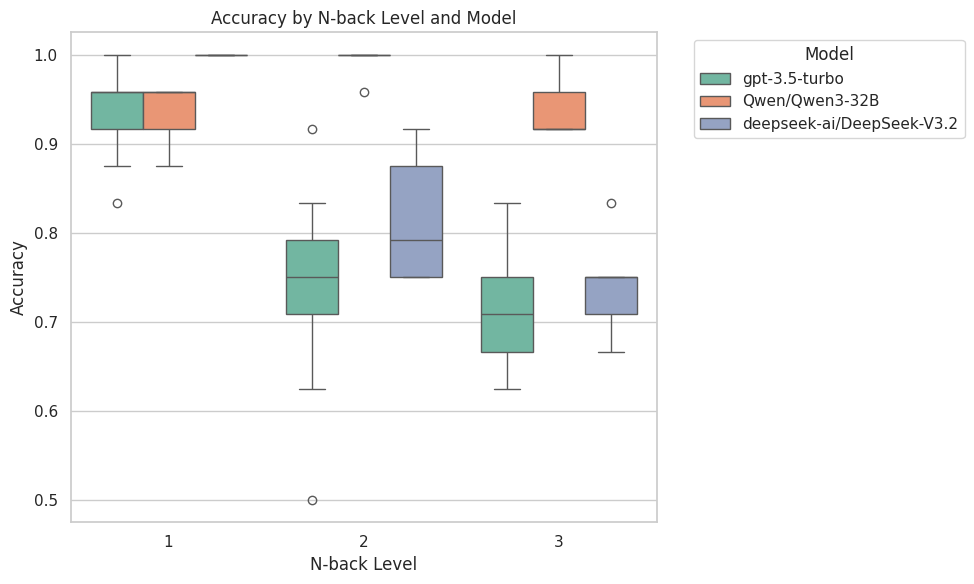

Boxplot for hit_rate by N-back Level (Models Compared):


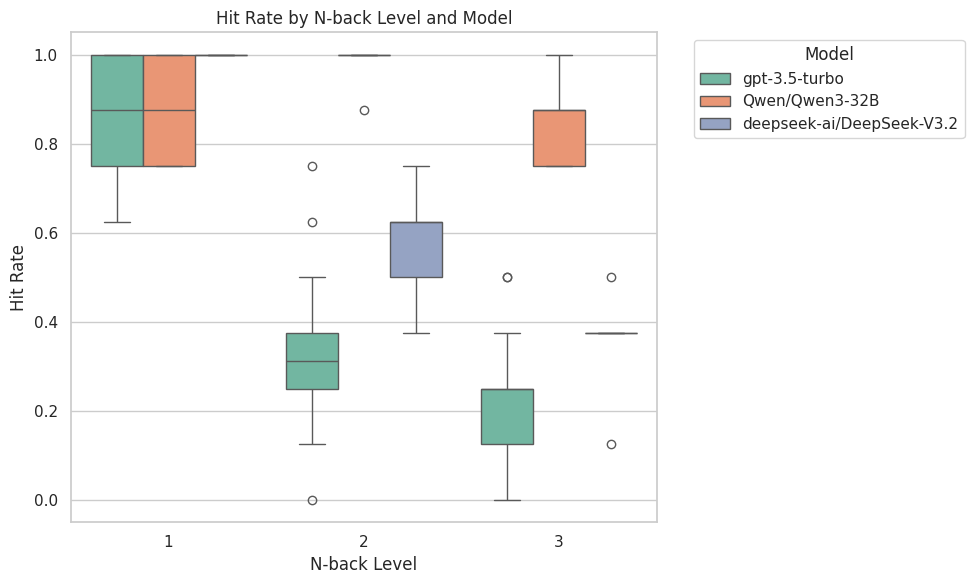

Boxplot for fa_rate by N-back Level (Models Compared):


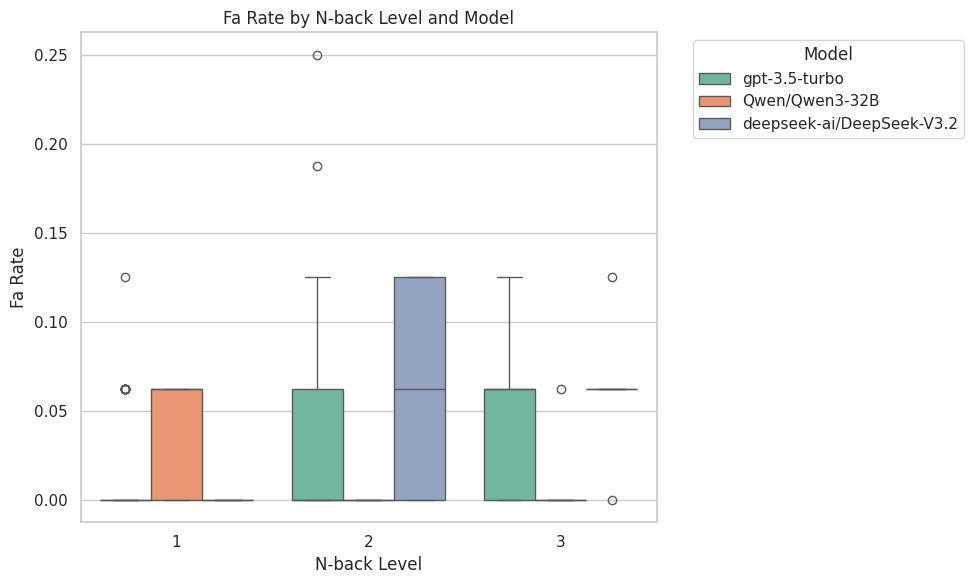

Line plot for d_prime trend across N-back Levels:


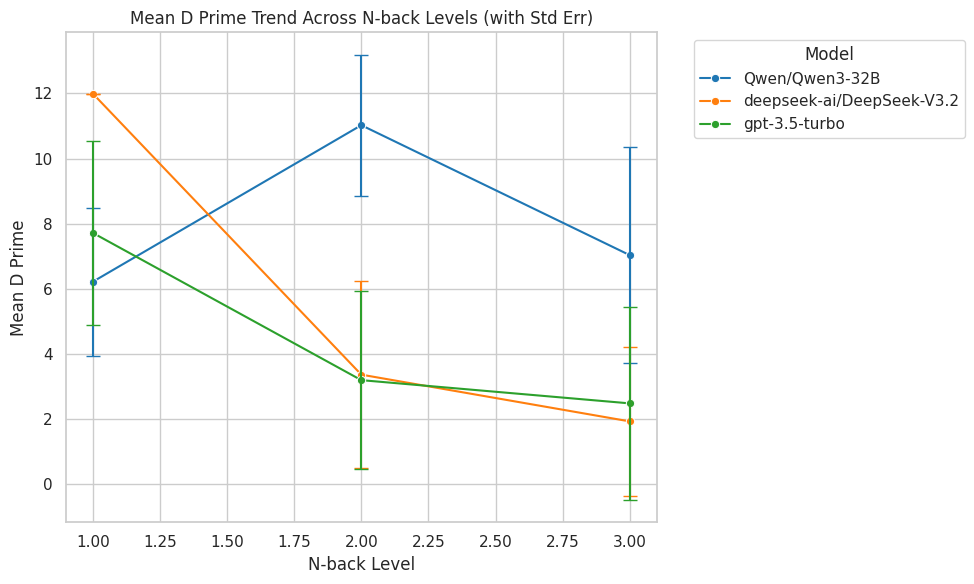

Line plot for accuracy trend across N-back Levels:


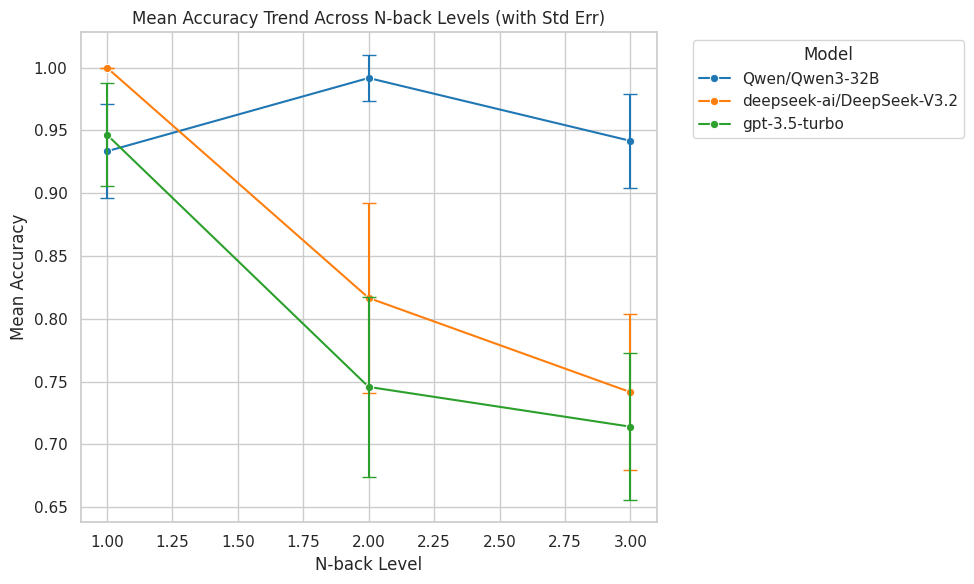

Line plot for hit_rate trend across N-back Levels:


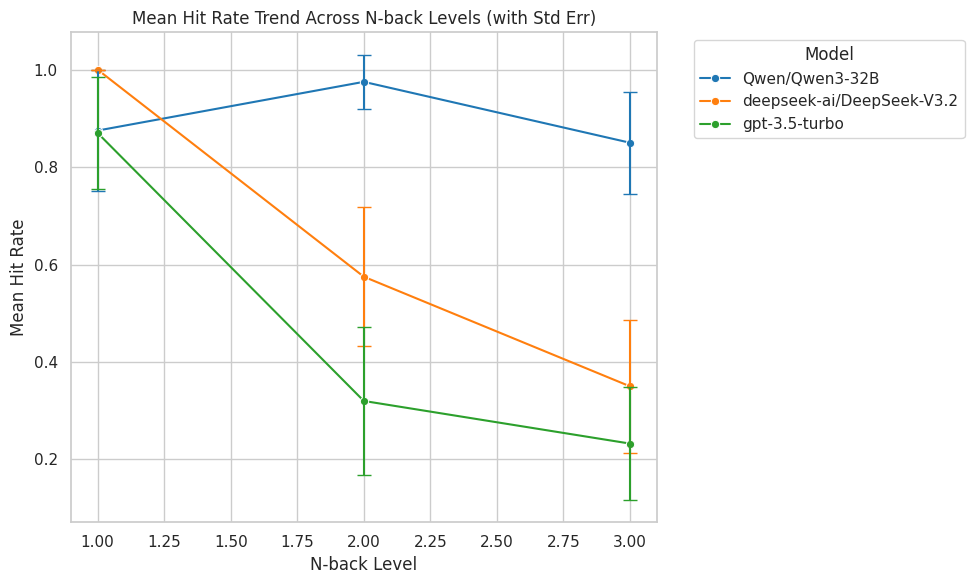

Line plot for fa_rate trend across N-back Levels:


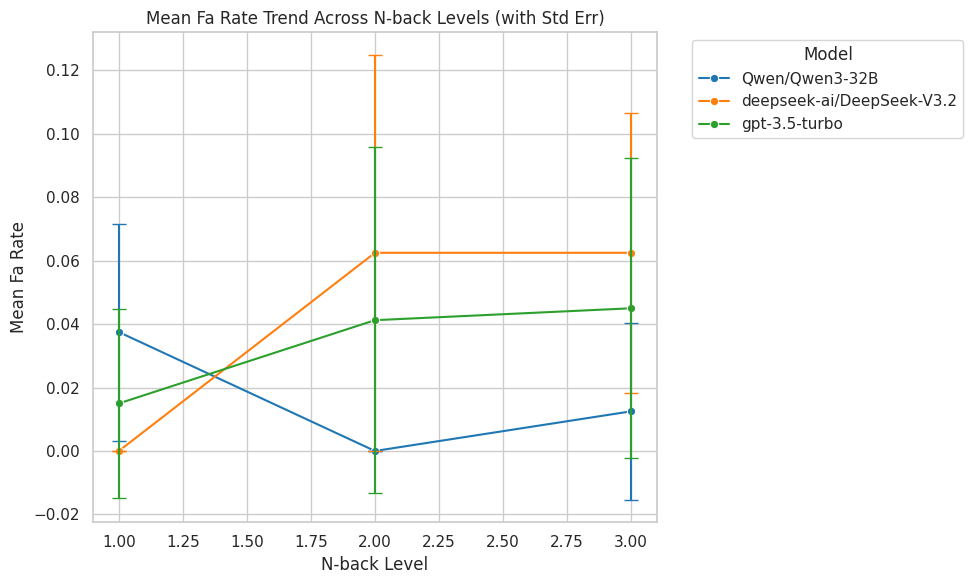


FacetGrid visualization (Metrics vs N-back, Faceted by Model):


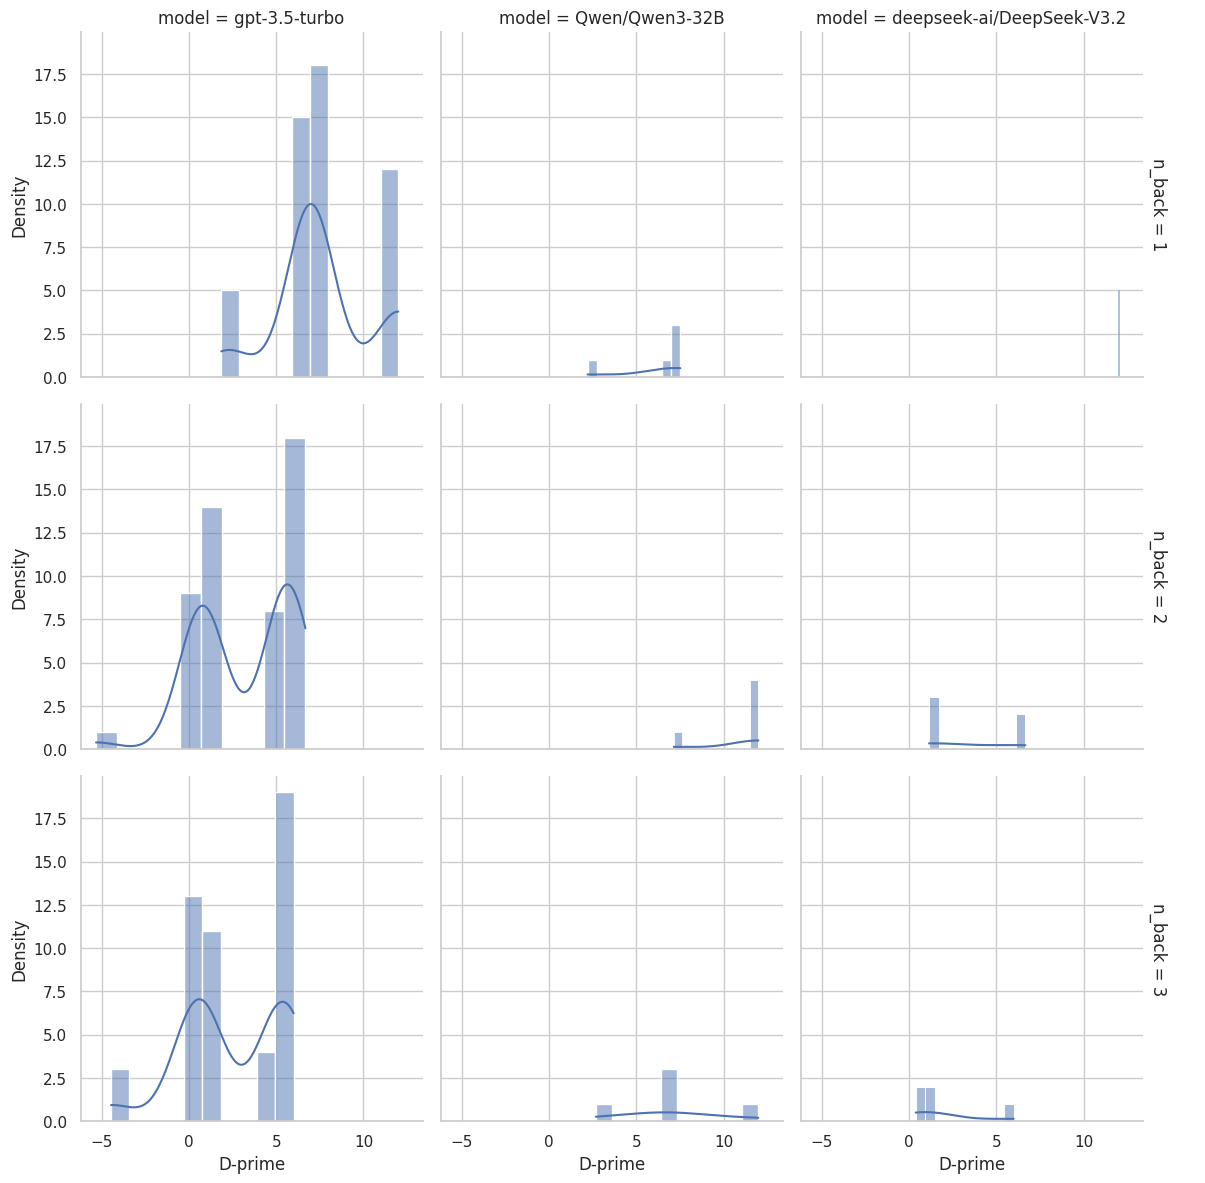

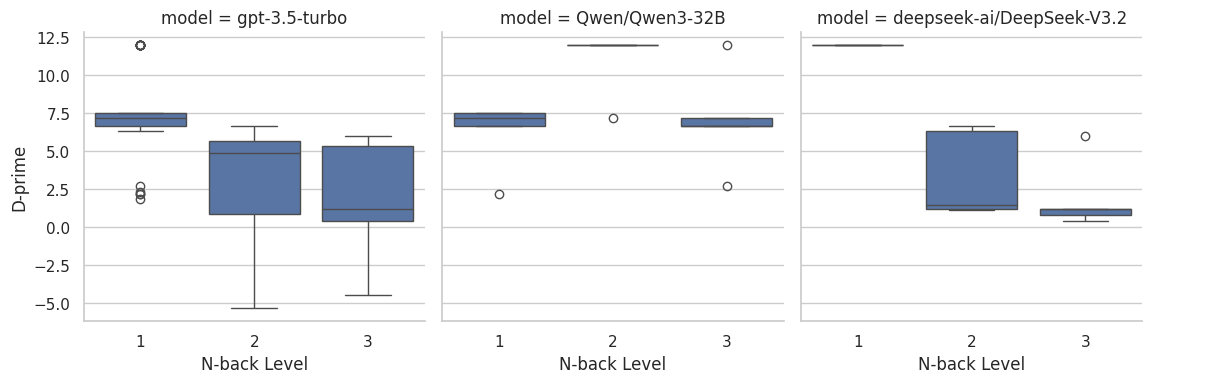

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator
import numpy as np

# --- 1. Distribution Plots for Key Metrics (Similar to verbal.ipynb) ---
def plot_distributions(dataframe, metrics, models, n_levels):
    """Plot histograms for specified metrics."""
    for metric in metrics:
        print(f"Distribution plot for {metric}:")
        # Prepare subplots: one row per model, or adjust based on number of models
        fig, axes = plt.subplots(len(models), len(n_levels), figsize=(len(n_levels)*4, len(models)*3))

        # Handle single row/column cases for axes indexing
        if len(models) == 1:
            axes = axes[np.newaxis, :]
        if len(n_levels) == 1:
            axes = axes[:, np.newaxis]

        for i, model in enumerate(models):
            for j, n in enumerate(n_levels):
                model_n_data = dataframe[(dataframe['model'] == model) & (dataframe['n_back'] == n)]
                if not model_n_data.empty:
                    sns.histplot(model_n_data[metric], ax=axes[i, j], color="blue", bins=10, kde=True, stat='count')
                    axes[i, j].set_title(f"{model} - {n}-back", fontsize=12)
                    axes[i, j].set_xlabel(metric.replace("_", " ").title())
                    axes[i, j].set_ylabel("Count")
                    axes[i, j].spines['top'].set_visible(False)
                    axes[i, j].spines['right'].set_visible(False)
                    axes[i, j].grid(False)
                    axes[i, j].spines['bottom'].set_linewidth(1.5)
                    axes[i, j].spines['left'].set_linewidth(1.5)
                    axes[i, j].spines['bottom'].set_color('black')
                    axes[i, j].spines['left'].set_color('black')
                    axes[i, j].tick_params(axis='both', which='both', bottom=True, left=True)
                    axes[i, j].yaxis.set_major_locator(MaxNLocator(integer=True))
                else:
                    axes[i, j].set_title(f"No Data: {model} - {n}-back")
                    axes[i, j].text(0.5, 0.5, 'No Data', horizontalalignment='center', verticalalignment='center', transform=axes[i, j].transAxes)

        plt.tight_layout()
        plt.show()

# --- 2. Box Plots Grouped by N-back Level (Across Models) ---
def plot_boxplots_by_n(dataframe, metrics, n_levels):
    """Create boxplots grouped by N-back level."""
    for metric in metrics:
        print(f"Boxplot for {metric} by N-back Level (Models Compared):")
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=dataframe, x='n_back', y=metric, hue='model', palette='Set2')
        plt.title(f'{metric.replace("_", " ").title()} by N-back Level and Model')
        plt.xlabel('N-back Level')
        plt.ylabel(metric.replace('_', ' ').title())
        plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

# --- 3. Line Plots (Mean with Error Bars) for N-back Trends ---
def plot_lineplots(dataframe, metrics):
    """Create line plots showing trends across N-back levels."""
    for metric in metrics:
        print(f"Line plot for {metric} trend across N-back Levels:")
        plt.figure(figsize=(10, 6))

        # Calculate mean and std for error bars
        agg_data = dataframe.groupby(['model', 'n_back'])[metric].agg(['mean', 'std']).reset_index()

        sns.lineplot(data=agg_data, x='n_back', y='mean', hue='model', marker='o', palette='tab10')

        # Add error bars manually (requires a bit more work)
        for model in agg_data['model'].unique():
            model_data = agg_data[agg_data['model'] == model]
            plt.errorbar(model_data['n_back'], model_data['mean'], yerr=model_data['std'],
                         fmt='none', capsize=5, capthick=1, ecolor=sns.color_palette('tab10')[list(agg_data['model'].unique()).index(model)])

        plt.title(f'Mean {metric.replace("_", " ").title()} Trend Across N-back Levels (with Std Err)')
        plt.xlabel('N-back Level')
        plt.ylabel(f'Mean {metric.replace("_", " ").title()}')
        plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

# --- Execute Visualization Functions ---
# Define metrics, models, and n_levels to visualize
metrics_to_plot = ['d_prime', 'accuracy', 'hit_rate', 'fa_rate']
models_to_plot = sorted(combined_df['model'].unique())
n_levels_to_plot = sorted(combined_df['n_back'].unique())

# 1. Distribution plots
plot_distributions(combined_df, metrics_to_plot, models_to_plot, n_levels_to_plot)

# 2. Box plots grouped by N-back level
plot_boxplots_by_n(combined_df, metrics_to_plot, n_levels_to_plot)

# 3. Line plots showing trends
plot_lineplots(combined_df, metrics_to_plot)

# --- Optional: FacetGrid for a comprehensive view ---
print("\nFacetGrid visualization (Metrics vs N-back, Faceted by Model):")
g = sns.FacetGrid(combined_df, col='model', row='n_back', margin_titles=True, height=4)
g.map(sns.histplot, 'd_prime', bins=10, kde=True).add_legend()
g.set_axis_labels('D-prime', 'Density')
plt.show()

g2 = sns.FacetGrid(combined_df, col='model', margin_titles=True, height=4)
g2.map(sns.boxplot, 'n_back', 'd_prime').add_legend()
g2.set_axis_labels('N-back Level', 'D-prime')
plt.show()